### Setup base model and data

In [ ]:

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os

from ablation_utils.uncertainty import (
    UncertaintyData, ProbabilityEnsemble,
    ConstantEU, EntropyEU, VarianceEU, KNNRadius, MMIUncertainty, conformal_pvalues_loo, conformal_pvalues
)
from sklearn.linear_model import LogisticRegression

os.makedirs("plots", exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [32]:
# Leave exactly one `data = ...` block uncommented

from ablation_utils.data import blobs, pendigits, fashion_mnist

#data = pendigits(eu_classes=(5, 6, 7, 8, 9), eu_keep=0.25, seed=0)
#dataname="PENDIGITS"
#data = blobs(eu_classes=(5, 6, 7, 8), eu_keep=0.1, seed=0)
#dataname="BLOBS"
data = fashion_mnist(eu_keep=0.3, n_train=10000, n_calib=5000, n_test=20000,seed=0)
dataname="FASHION_MNIST"


X_train, y_train = data.X_train, data.y_train
X_calib, y_calib = data.X_calib, data.y_calib
X_test,  y_test  = data.X_test,  data.y_test

num_classes = data.num_classes
n_calib     = data.n_calib
group_test   = data.group_test      

print(data.summary())

fashion-mnist: K = 10, n_train = 6519, n_calib = 5000, n_test = 20000
  eu classes     [4, 5, 6, 7, 8]
  train / class  [1012, 1040, 990, 1015, 302, 303, 292, 293, 302, 970]
  rest   train   5027   test   9986
  eu     train   1492   test  10014


In [33]:
# model = RandomForestClassifier(n_estimators=100, max_iter=1000)
# model.fit(X_train, y_train)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# adjust max_depth to make model more or less capable
# 6 was used for blobs and digits data
model = ProbabilityEnsemble(DecisionTreeClassifier(), k=25)
model.fit(X_train, y_train)

def scores_all(Xa):
    """(m, K) matrix of S(x, y) for every candidate label y."""
    return 1.0 - model.predict_proba(Xa)
    #P = np.clip(model.predict_proba(Xa), 1e-12, 1.0)
    #return -np.log(P)    

S_calib_all = scores_all(X_calib)                    # (n_calib, K)
S_calib = S_calib_all[np.arange(n_calib), y_calib]   # (n_calib,)
S_test_all = scores_all(X_test)
S_test  = S_test_all[np.arange(len(X_test)), y_test]
acc = model.score(X_train, y_train)

print("base model accuracy (calib):", (model.predict(X_calib) == y_calib).mean())

base model accuracy (calib): 0.8146


### Training a model of coverage levels

In [34]:
# set up for ablation - determine uncertainty methods to use
uncertainty_methods = {
    "constant": ConstantEU(),
    "entropy":  EntropyEU(model),
    "variance": VarianceEU(model),
    "knn":      KNNRadius(n_neighbors=25, standardize=False),
    "mmi_pi":   MMIUncertainty(form="pi"),
}

In [35]:
# construct the loo data needed for all uncertainty methods

n_loo = n_calib - 1
Sigma_loo = S_calib.sum() - S_calib                
E_loo = (n_loo + 1) * S_calib_all / (Sigma_loo[:, None] + S_calib_all)   
feats_loo = np.concatenate([Sigma_loo[:, None], np.sort(S_calib_all, axis=1)], axis=1)
P_loo     = conformal_pvalues_loo(S_calib, S_calib_all)


In [36]:
# bundle the calibration data
train_data = UncertaintyData(X=X_train)
calib_data = UncertaintyData(X=X_calib, E=E_loo, S=S_calib_all, P=P_loo)

for method in uncertainty_methods.values():
    method.fit(train_data).calibrate(calib_data)


In [37]:
# setup for statistical tests
EU      = (data.group_test == "eu")          
METHODS = list(uncertainty_methods)
AWARE   = [m for m in METHODS if m != "constant"]
print(f"eu: {EU.sum()}   rest: {(~EU).sum()}   eu_classes: {data.eu_classes}")

eu: 10014   rest: 9986   eu_classes: (4, 5, 6, 7, 8)


In [38]:
print(f"highest recommended lambda: {(num_classes-1) * E_loo.max()}")
lam=int(((num_classes-1) * E_loo.max())//5)*5

highest recommended lambda: 31.51701919036279


In [39]:
# exact minimiser of L(alpha) = Size(alpha) + lambda * c(u) * alpha 
def exact_size(Sigma, s_cand, n, alpha):
    if alpha <= 1.0 / (n + 1):
        return len(s_cand)                      
    tau = Sigma / ((n + 1) * alpha - 1.0)
    return int(np.sum(s_cand <= tau))

def covered(Sigma, s_true, n, alpha):
    E_true = (n + 1) * s_true / (Sigma + s_true)
    return E_true <= 1.0 / alpha


def exact_min(Sigma, s_cand, n, u_cand, lam, c=1, eps=1e-6):
    s_sorted = np.sort(s_cand)
    breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)          
    cands = np.concatenate([breakpoints + eps, [1.0 / (n + 1) + eps, 1.0]])
    cands = np.unique(cands[(cands > 1.0 / (n + 1)) & (cands <= 1.0)])
    losses = np.array([exact_size(Sigma, s_cand, n, a) + lam * u_cand * c * a for a in cands])
    j = int(np.argmin(losses))
    return float(cands[j]), float(losses[j])

def per_point(alphas, Sigma=Sigma_loo, S_all=S_calib_all, S_true=S_calib, n=n_loo):
    sizes = np.array([exact_size(Sigma[i], S_all[i], n, alphas[i]) for i in range(len(alphas))])
    miss  = np.array([not covered(Sigma[i], S_true[i], n, alphas[i]) for i in range(len(alphas))])
    return sizes, miss

def set_metrics_exact(alphas, sizes, miss, u, lam, c=1):
    a_mean  = float(alphas.mean())
    cov     = 1.0 - float(miss.mean())
    nominal = 1.0 - a_mean
    return {
        "mean alpha":  a_mean,
        "nominal cov": nominal,
        "coverage":    cov,
        "gap":         cov - nominal,                               
        "mean size":   float(sizes.mean()),
        "% empty":     100.0 * float(np.mean(sizes == 0)),
        "EU unaware loss":        float(sizes.mean() + lam * a_mean),          
        "objective":   float(np.mean(sizes + lam * c * u * alphas)),
    }
    print()

###  coverage policy evaluation

In [40]:
import pandas as pd

# test-split inputs (same as cell 16; safe to redefine)
Sigma_test = float(S_calib.sum())
E_test     = (n_calib + 1) * S_test_all / (Sigma_test + S_test_all)
test_data  = UncertaintyData(X=X_test, E=E_test, S=S_test_all,
                             P=conformal_pvalues(S_calib, S_test_all))
n_test = len(X_test)

EU_test = np.isin(y_test, data.eu_classes)
GROUPS = [("all", np.ones(n_test, bool)), ("High EU", EU_test), ("Low EU", ~EU_test)]

results, rows = {}, {}
for name, method in uncertainty_methods.items():
    u = np.asarray(method.transform_normalized(test_data), dtype=float).reshape(-1)
    a_ex = np.array([exact_min(Sigma_test, S_test_all[i], n_calib, u[i], lam, c=1)[0]
                     for i in range(n_test)])
    sizes, miss = per_point(a_ex, Sigma=np.full(n_test, Sigma_test),
                            S_all=S_test_all, S_true=S_test, n=n_calib)
    results[name] = {"alpha": a_ex, "size": sizes, "miss": miss, "u": u}
    for g, m in GROUPS:
        rows[(name, g)] = set_metrics_exact(a_ex[m], sizes[m], miss[m], u[m], lam)

df_table = pd.DataFrame.from_dict(rows, orient="index")
df_table.index = pd.MultiIndex.from_tuples(df_table.index, names=["method", "group"])

print(f"Test split, n_test = {n_test}, n_calib = {n_calib}, lambda = {lam}, c = 1   "
      f"(High EU {EU_test.sum()}, Low EU {(~EU_test).sum()})")
print("gap = coverage - (1 - mean alpha); negative means over-promised\n")
print(df_table.round(3).to_string())

latex = df_table.round(3).to_latex(
    float_format="%.3f",
    column_format="ll" + "r" * df_table.shape[1],
    multirow=True,
    caption=rf"Exact minimiser on the test split ($\lambda={lam}$, $n={n_calib}$). "
            r"Gap $=$ coverage $-(1-\bar{\tilde\alpha})$; loss $=$ size $+\lambda\bar{\tilde\alpha}$; "
            r"objective $=$ size $+\lambda c\,u\,\tilde\alpha$.",
    label=f"tab:exact-min-{dataname.lower()}",
).replace("%", r"\%")
print("\n" + latex)

C:\Users\User\AppData\Local\Temp\ipykernel_21968\1349704727.py:15: RuntimeWarning: divide by zero encountered in divide
  breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)
C:\Users\User\AppData\Local\Temp\ipykernel_21968\1349704727.py:15: RuntimeWarning: divide by zero encountered in divide
  breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)
C:\Users\User\AppData\Local\Temp\ipykernel_21968\1349704727.py:15: RuntimeWarning: divide by zero encountered in divide
  breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)
C:\Users\User\AppData\Local\Temp\ipykernel_21968\1349704727.py:15: RuntimeWarning: divide by zero encountered in divide
  breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)


Test split, n_test = 20000, n_calib = 5000, lambda = 30, c = 1   (High EU 10014, Low EU 9986)
gap = coverage - (1 - mean alpha); negative means over-promised

                  mean alpha  nominal cov  coverage    gap  mean size  % empty  EU unaware loss  objective
method   group                                                                                            
constant all           0.119        0.881     0.986  0.105      6.307     0.00            9.879      9.879
         High EU       0.075        0.925     0.974  0.049      7.698     0.00            9.947      9.947
         Low EU        0.163        0.837     0.997  0.161      4.912     0.00            9.810      9.810
entropy  all           0.150        0.850     0.976  0.126      5.437     0.00            9.925      6.581
         High EU       0.108        0.892     0.956  0.064      6.768     0.00            9.997      8.005
         Low EU        0.192        0.808     0.996  0.188      4.104     0.00            9.

In [41]:
import pingouin as pg
from statsmodels.stats.multitest import multipletests

# setup (LOO analogue of the test-split cell)
EU      = EU_test
METHODS = list(uncertainty_methods)
CONTROL = "constant"
AWARE   = [m for m in METHODS if m != CONTROL]

OUTCOMES = {
    "alpha":       {m: results[m]["alpha"]                  for m in METHODS},
    "size":        {m: results[m]["size"].astype(float)     for m in METHODS},
    "miscoverage": {m: results[m]["miss"].astype(float)     for m in METHODS},
}

DATA = {
    metric: pd.DataFrame([
        {"id": i, "Method": m, "Region": "High EU" if EU[i] else "Low EU", "value": float(V[m][i])}
        for i in range(len(X_test)) for m in METHODS
    ])
    for metric, V in OUTCOMES.items()
}


In [42]:


ANOVA_RESULTS = {}
for metric, d in DATA.items():
    aov = pg.mixed_anova(data=d, dv="value", within="Method", between="Region", subject="id")
    ANOVA_RESULTS[metric] = aov
    print(f"\n{'='*70}\n{metric.upper()} — MIXED ANOVA\n{'='*70}")
    print(aov.round(4).to_string(index=False))



ALPHA — MIXED ANOVA
     Source       SS  DF1   DF2       MS         F  p_unc  p_GG_corr    np2    eps sphericity  W_spher  p_spher
     Region 174.6861    1 19998 174.6861 2567.3512    0.0        NaN 0.1138    NaN        NaN      NaN      NaN
     Method  50.2165    4 79992  12.5541 1696.4166    0.0        0.0 0.0782 0.6719      False   0.2649      0.0
Interaction   1.9217    4 79992   0.4804   64.9185    0.0        NaN 0.0032    NaN        NaN      NaN      NaN

SIZE — MIXED ANOVA
     Source          SS  DF1   DF2          MS         F  p_unc  p_GG_corr    np2    eps sphericity  W_spher  p_spher
     Region 177065.7052    1 19998 177065.7052 2716.3143    0.0        NaN 0.1196    NaN        NaN      NaN      NaN
     Method  41971.3013    4 79992  10492.8253 1735.5116    0.0        0.0 0.0799 0.6665      False   0.2648      0.0
Interaction   1655.8485    4 79992    413.9621   68.4693    0.0        NaN 0.0034    NaN        NaN      NaN      NaN

MISCOVERAGE — MIXED ANOVA
     Source 

In [43]:
DID_RESULTS = {}
for metric, V in OUTCOMES.items():
    rows_did = []
    for m in AWARE:
        gap = V[m] - V[CONTROL]
        high, low = gap[EU], gap[~EU]
        r = pg.ttest(high, low, paired=False, correction=True).iloc[0]
        rows_did.append({
            "Method": m, "Delta_High": high.mean(), "Delta_Low": low.mean(),
            "DiD": high.mean() - low.mean(),
            "CI95_low": r["CI95"][0], "CI95_high": r["CI95"][1],
            "Cohen_d": r["cohen_d"], "T": r["T"], "dof": r["dof"], "p": r["p_val"],
        })
    res = pd.DataFrame(rows_did)
    res["p_holm"] = multipletests(res["p"], method="holm")[1]
    DID_RESULTS[metric] = res
    print(f"\n{'='*80}\n{metric.upper()} — DIFFERENCE-IN-DIFFERENCES\n{'='*80}")
    print(res.round(4).to_string(index=False))



ALPHA — DIFFERENCE-IN-DIFFERENCES
  Method  Delta_High  Delta_Low     DiD  CI95_low  CI95_high  Cohen_d       T        dof      p  p_holm
 entropy      0.0327     0.0283  0.0044      0.00       0.01   0.0453  3.2064 19853.6951 0.0013  0.0027
variance      0.0378     0.0320  0.0058      0.00       0.01   0.0585  4.1354 19888.8449 0.0000  0.0001
     knn      0.0133     0.0198 -0.0065     -0.01      -0.00   0.0435 -3.0746 19737.0387 0.0021  0.0027
  mmi_pi      0.0775     0.0575  0.0200      0.02       0.02   0.1548 10.9493 19772.7784 0.0000  0.0000

SIZE — DIFFERENCE-IN-DIFFERENCES
  Method  Delta_High  Delta_Low     DiD  CI95_low  CI95_high  Cohen_d        T        dof      p  p_holm
 entropy     -0.9307    -0.8088 -0.1219     -0.20      -0.05   0.0442  -3.1239 19852.5909 0.0018  0.0018
variance     -1.0826    -0.9176 -0.1650     -0.24      -0.09   0.0581  -4.1055 19889.9994 0.0000  0.0001
     knn     -0.2501    -0.4759  0.2257      0.11       0.35   0.0519   3.6669 19746.1705 0.0002

In [44]:
POSTHOC_RESULTS = {}
for metric, d in DATA.items():
    ph = pg.pairwise_tests(dv="value", within="Method", between="Region",
                           subject="id", data=d, padjust="holm", correction=True)
    POSTHOC_RESULTS[metric] = ph
    print(f"\n{'='*80}\n{metric.upper()} — POST-HOC (Holm)\n{'='*80}")
    print(ph.round(4).to_string(index=False))


ALPHA — POST-HOC (Holm)
       Contrast   Method        A        B Paired Parametric        T        dof alternative  p_unc  p_corr p_adjust       BF10  hedges
         Method        - constant  entropy   True       True -44.8234 19999.0000   two-sided    0.0     0.0     holm        inf -0.2109
         Method        - constant      knn   True       True -15.5271 19999.0000   two-sided    0.0     0.0     holm  8.573e+49 -0.1139
         Method        - constant   mmi_pi   True       True -73.6223 19999.0000   two-sided    0.0     0.0     holm        inf -0.4691
         Method        - constant variance   True       True -49.8061 19999.0000   two-sided    0.0     0.0     holm        inf -0.2409
         Method        -  entropy      knn   True       True  13.4997 19999.0000   two-sided    0.0     0.0     holm  1.952e+37  0.0949
         Method        -  entropy   mmi_pi   True       True -51.7382 19999.0000   two-sided    0.0     0.0     holm        inf -0.2531
         Method        

In [45]:
def set_metrics(coverages, sizes, alphas):
    cov     = float(np.mean(coverages))
    a_mean  = float(np.mean(alphas))
    nominal = 1.0 - a_mean
    return {
        "mean alpha":  a_mean,
        "nominal cov": nominal,
        "coverage":    cov,
        "gap":         cov - nominal,       
        "mean size":   float(np.mean(sizes)),
        "% empty":     100.0 * np.mean(np.asarray(sizes) == 0),
    }

In [ ]:
import ablation_utils.neural_net as anet
rows, curves, sizes_for_hist, raw = {}, {}, {}, {}

for name in uncertainty_methods:
    cov = 1.0 - results[name]["miss"].astype(float)
    sz  = results[name]["size"]
    a   = results[name]["alpha"]
    rows[name]           = set_metrics(cov, sz, a)
    raw[name]            = [(cov, sz, a)]          # one "run": exact minimiser is deterministic
    curves[name]         = anet.reliability(cov, a)
    sizes_for_hist[name] = sz

C:\Users\User\AppData\Local\Temp\ipykernel_21968\1106523379.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


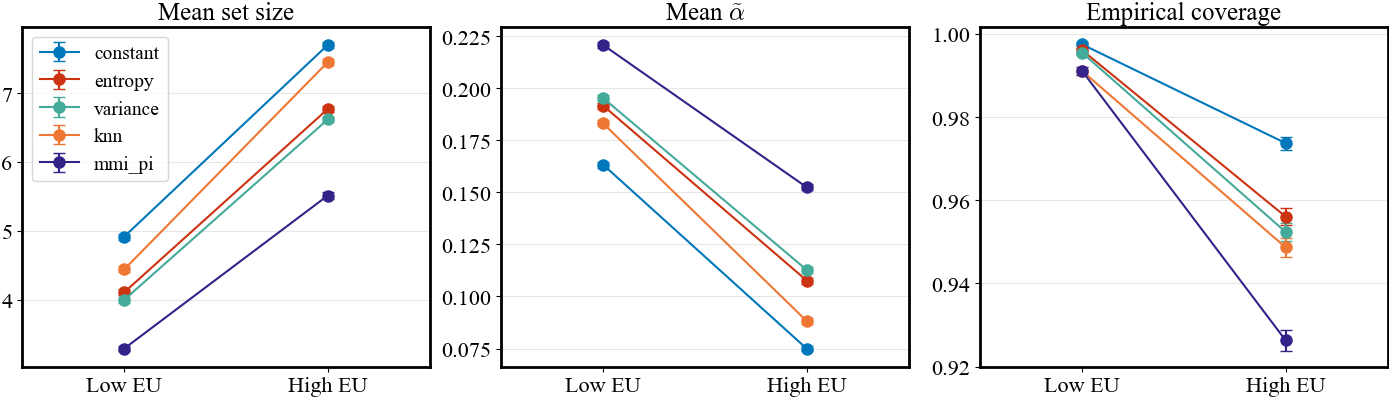

In [47]:
import matplotlib.pyplot as plt
from tueplots import bundles

def to_np(v):
    return v.detach().cpu().numpy() if hasattr(v, "detach") else np.asarray(v)

GROUPS  = ["rest", "eu"]
LABEL   = {"rest": "Low EU", "eu": "High EU"}
METRICS = [("size",     "Mean set size"),
           ("alpha",    r"Mean $\tilde\alpha$"),
           ("coverage", "Empirical coverage")]

g_np   = np.asarray(group_test)
groups = [g for g in GROUPS if (g_np == g).any()]
names  = list(raw)
colors = dict(zip(names, anet._PALETTE))

plt.rcParams.update(bundles.icml2024(usetex=False))
plt.rcParams.update({
    "axes.labelsize": 18, "axes.titlesize": 18,
    "xtick.labelsize": 16, "ytick.labelsize": 16,
    "legend.fontsize": 14, "lines.linewidth": 2, "axes.linewidth": 2,
})

def draw(ax, mean, se, x, color, label):
    ax.errorbar(x, mean, yerr=se, color=color, label=label,
                marker="o", markersize=8, linewidth=1.5, capsize=4, elinewidth=1.5)

def style(ax, labels, title):
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(labels) - 0.5)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)

def group_stats(cov, sz, a, m):
    """mean and standard error of the mean over test points in group m"""
    out = {}
    for k, v in (("size", sz), ("alpha", a), ("coverage", cov)):
        v = to_np(v).astype(float)[m]
        out[k] = (v.mean(), v.std(ddof=1) / np.sqrt(len(v)))
    return out

stat = {n: {g: group_stats(*raw[n][0], g_np == g) for g in groups} for n in names}

fig, axs = plt.subplots(1, len(METRICS), figsize=(4.7 * len(METRICS), 4.2))
for ax, (key, title) in zip(axs, METRICS):
    for n in names:
        mean = [stat[n][g][key][0] for g in groups]
        se   = [stat[n][g][key][1] for g in groups]
        draw(ax, mean, se, np.arange(len(groups)), colors[n], n)
    style(ax, [LABEL[g] for g in groups], title)
axs[0].legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig(f"plots/groups_by_method_{dataname}_data_exact.pdf", bbox_inches="tight")
plt.show()

In [48]:
# Class-wise MISCOVERAGE (1 - coverage), exact minimiser on the test split
HIGHER_IS_HARDER = True          # True if S is a nonconformity score, False if it's a softmax prob

S_np = np.asarray(S_test_all)
y_np = np.asarray(y_test).astype(int)
names = list(results)

true_score = S_np[np.arange(len(y_np)), y_np]
classes    = np.unique(y_np)
order      = np.argsort([true_score[y_np == c].mean() for c in classes])
classes    = classes[order if HIGHER_IS_HARDER else order[::-1]]   # easy -> hard

cmis = {n: np.array([results[n]["miss"][y_np == cl].mean() for cl in classes]) for n in names}
marg = {n: float(results[n]["miss"].mean()) for n in names}

summary = pd.DataFrame({n: {
    "marginal miscov":  marg[n],
    "max - min":        cmis[n].max() - cmis[n].min(),
    "max class miscov": cmis[n].max(),
} for n in names}).T

eu_set = set(np.atleast_1d(data.eu_classes).tolist())
per_class = pd.DataFrame({n: cmis[n] for n in names},
                         index=[f"{c}*" if c in eu_set else str(c) for c in classes]).T
per_class.columns.name = "class (easy -> hard), * = EU class"

print(f"Test split, n_test = {len(y_np)}, lambda = {lam}")
print("Smaller max-min = miscoverage more uniform across classes\n")
print(summary.round(3).to_string(), "\n")
print("Class miscoverage")
print(per_class.round(3).to_string(), "\n")

latex_summary = summary.round(3).to_latex(
    float_format="%.3f", column_format="l" + "r" * summary.shape[1],)

Test split, n_test = 20000, lambda = 30
Smaller max-min = miscoverage more uniform across classes

          marginal miscov  max - min  max class miscov
constant            0.014      0.078             0.078
entropy             0.024      0.128             0.129
variance            0.026      0.137             0.138
knn                 0.030      0.151             0.152
mmi_pi              0.041      0.201             0.206 

Class miscoverage
class (easy -> hard), * = EU class      1      9      0      3     8*     5*      2     7*     4*     6*
constant                            0.001  0.002  0.004  0.003  0.001  0.002  0.003  0.024  0.025  0.078
entropy                             0.002  0.003  0.005  0.006  0.001  0.004  0.004  0.036  0.047  0.129
variance                            0.002  0.003  0.007  0.006  0.002  0.004  0.005  0.038  0.054  0.138
knn                                 0.006  0.004  0.014  0.011  0.001  0.002  0.010  0.031  0.067  0.152
mmi_pi                    